# Delta p Spectra: Load, Plot, and Surrogate Training

This notebook demonstrates:
1. **Loading** from per-run `sdata_pertfields_grid_complex_v2.h5` files (one per `run*/sparc_*/`)
2. **Plotting** 2D fields, complex components, and modes spectrum using helpers from `plot_sdata_pertfields.py`
3. **Dataset generator** that scans all runs, pulls the right fields, and builds a DataFrame for SURGE
4. **SURGE dataloader** integration for training on the modes spectrum

Data: `/pscratch/sd/a/asvillar/mp288/jobs/batch_16/` (each `run1/sparc_1300/`, etc. has its own complex_v2 file).

In [8]:
# Setup paths and imports
import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

# SURGE and M3DC1 loader
surge_root = Path("/global/homes/a/asvillar/src/SURGE").resolve()
if str(surge_root) not in sys.path:
    sys.path.insert(0, str(surge_root))

scripts_m3dc1 = surge_root / "scripts" / "m3dc1"
if str(scripts_m3dc1) not in sys.path:
    sys.path.insert(0, str(scripts_m3dc1))

# Notebook-local plotting helpers and m3dc1_python_code
nb_m3dc1 = surge_root / "notebooks" / "m3dc1"
if str(nb_m3dc1) not in sys.path:
    sys.path.insert(0, str(nb_m3dc1))

m3dc1_code = nb_m3dc1 / "m3dc1_python_code"
if m3dc1_code.exists() and str(m3dc1_code) not in sys.path:
    sys.path.insert(0, str(m3dc1_code))

# Data directory: per-run sdata_pertfields_grid_complex_v2.h5 in run*/sparc_*/
BATCH_DIR = Path("/pscratch/sd/a/asvillar/mp288/jobs/batch_16")
COMPLEX_V2_FILENAME = "sdata_pertfields_grid_complex_v2.h5"

from loader import find_complex_v2_files
paths = find_complex_v2_files(BATCH_DIR, filename=COMPLEX_V2_FILENAME)
print(f"Batch dir: {BATCH_DIR}")
print(f"Found {len(paths)} per-run {COMPLEX_V2_FILENAME} files")
if paths:
    print(f"  Example: {paths[30].relative_to(BATCH_DIR)}")

Batch dir: /pscratch/sd/a/asvillar/mp288/jobs/batch_16
Found 31 per-run sdata_pertfields_grid_complex_v2.h5 files
  Example: run1/sparc_1425/sdata_pertfields_grid_complex_v2.h5


## 1. Inspect per-run sdata_pertfields_grid_complex_v2.h5 structure

In [9]:
# Inspect first per-run complex_v2 file (each file = one case)
h5_path = paths[0] if paths else None
if h5_path:
    with h5py.File(h5_path, "r") as h5:
        print("Root keys:", list(h5.keys()))
        if "runs" in h5:
            r0 = list(h5["runs"].keys())[0]
            rg = h5["runs"][r0]
            print(f"Run {r0} keys: {list(rg.keys())}")
            if "spectrum" in rg:
                for name in ["p", "bphi"]:
                    if name in rg["spectrum"]:
                        sp = rg["spectrum"][name]
                        print(f"  spectrum/{name}: spec={sp['spec'].shape}, m_modes={sp['m_modes'].shape}, psi_norm={sp['psi_norm'].shape}")
            if "miller" in rg:
                print("  miller:", list(rg["miller"].keys()))
            if "parset" in rg:
                print("  parset names:", [x.decode() if hasattr(x, 'decode') else x for x in rg["parset"]["names"][:]])
            if "flux_average" in rg:
                print("  flux_average:", list(rg["flux_average"].keys()))
else:
    print("No complex_v2 files found.")

Root keys: ['mesh', 'runs']
Run run_0001 keys: ['eqID', 'equilibrium', 'flux_average', 'growth_rate', 'meshID', 'miller', 'parset', 'pertfields', 'q95', 'reconstruction_check', 'runID', 'spectrum', 'time', 'time_index']
  spectrum/p: spec=(2, 200, 200), m_modes=(200,), psi_norm=(200,)
  spectrum/bphi: spec=(2, 200, 200), m_modes=(200,), psi_norm=(200,)
  miller: ['R0', 'a', 'delta', 'kappa']
  parset names: ['ntor', 'pscale', 'batemanscale']
  flux_average: ['j', 'ne', 'ni', 'p', 'pe', 'pi', 'psi', 'q', 'te', 'ti']


## 2. Plot 2D perturbed fields

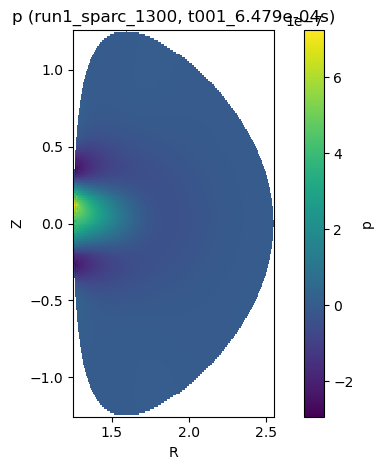

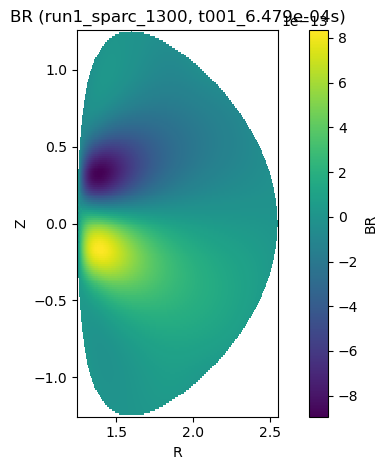

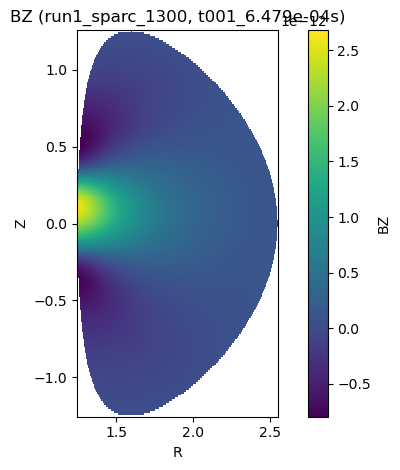

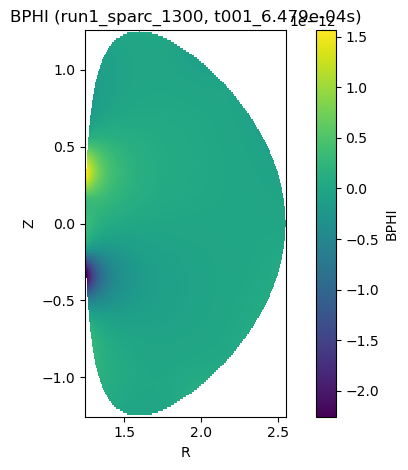

In [10]:
from plotting_helpers import (
    plot_2d_fields,
    plot_pertfield_complex,
    plot_spectrum,
    run_tag,
    _select_time_positions,
)

# Use first per-run complex_v2 file for plotting
h5_path = paths[0] if paths else None
if h5_path and h5_path.exists():
    with h5py.File(h5_path, "r") as h5:
        if "runs" in h5:
            run_name = list(h5["runs"].keys())[0]
            run_group = h5["runs"][run_name]
            tag = run_tag(run_group)
            time_index = np.asarray(run_group.get("time_index", []), dtype=int)
            time_values = np.asarray(run_group.get("time", []), dtype=float)
            time_positions = [time_index.size - 1] if time_index.size > 0 else []

            figs = plot_2d_fields(
                h5, run_group, tag, time_index, time_values, time_positions
            )
            if figs:
                for fig in figs:
                    plt.show(fig)
            else:
                print("No 2D field figures (pertfields may be missing or empty time)")
        else:
            print("No 'runs' group")
else:
    print("No complex_v2 files found for plotting.")

## 3. Plot complex perturbed field (magnitude, real, imag, phase)

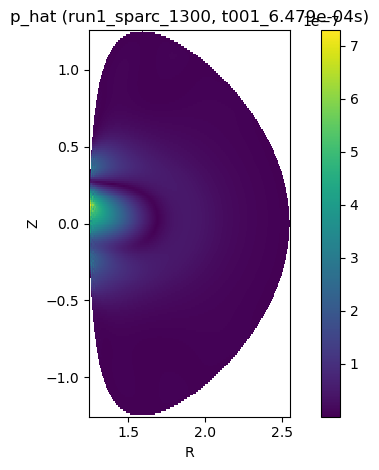

In [11]:
if h5_path and h5_path.exists():
    with h5py.File(h5_path, "r") as h5:
        if "runs" in h5:
            run_name = list(h5["runs"].keys())[0]
            run_group = h5["runs"][run_name]
            tag = run_tag(run_group)
            time_index = np.asarray(run_group.get("time_index", []), dtype=int)
            time_values = np.asarray(run_group.get("time", []), dtype=float)
            time_positions = [time_index.size - 1] if time_index.size > 0 else []

            for mode in ["hat-mag", "hat-real", "hat-imag"]:
                try:
                    fig = plot_pertfield_complex(
                        h5, run_group, tag, "p", mode,
                        time_index, time_values, time_positions
                    )
                    if fig is not None:
                        plt.show(fig)
                        break
                except Exception:
                    pass
            else:
                if "pertfields" in run_group and "p" in run_group["pertfields"]:
                    fig = plot_pertfield_complex(h5, run_group, tag, "p", "phi0")
                    if fig:
                        plt.show(fig)

## 4. Plot delta p spectrum (m-modes vs psi_N)

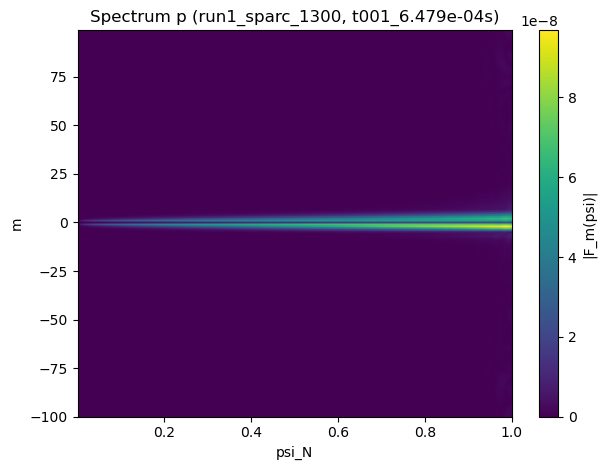

In [13]:
if h5_path and h5_path.exists():
    with h5py.File(h5_path, "r") as h5:
        if "runs" in h5:
            run_name = list(h5["runs"].keys())[0]
            run_group = h5["runs"][run_name]
            tag = run_tag(run_group)
            time_index = np.asarray(run_group.get("time_index", []), dtype=int)
            time_values = np.asarray(run_group.get("time", []), dtype=float)
            time_positions = [time_index.size - 1] if time_index.size > 0 else []

            fig = plot_spectrum(
                run_group, tag, field_name="p",
                time_index=time_index, time_values=time_values,
                time_positions=time_positions, scale="linear"
            )
            if fig is not None:
                plt.show(fig)

## 5. Dataset generator: build DataFrame from all per-run complex_v2 files

In [14]:
# Dataset generator: scans run*/sparc_* for sdata_pertfields_grid_complex_v2.h5,
# pulls inputs (miller, parset, flux_average) and outputs (spectrum/p modes)
from loader import load_complex_v2_for_surge

df, input_cols, output_cols = load_complex_v2_for_surge(
    BATCH_DIR,
    filename=COMPLEX_V2_FILENAME,
    spectrum_field="p",
    max_cases=None,  # use all; set e.g. 100 for quick testing
    mode_step=4,     # downsample: 200/4=50 modes (optional, omit for full 200x200)
    psi_step=4,      # downsample: 200/4=50 psi (yields 2500 outputs vs 40000)
)
print(f"DataFrame: {df.shape}")
print(f"Inputs: {input_cols}")
print(f"Outputs (spectrum): {len(output_cols)} components")

Loading 31 cases from /pscratch/sd/a/asvillar/mp288/jobs/batch_16
  Skip /pscratch/sd/a/asvillar/mp288/jobs/batch_16/run1/sparc_1300/sdata_pertfields_grid_complex_v2.h5: load_single_complex_v2() got an unexpected keyword argument 'mode_step'
  Skip /pscratch/sd/a/asvillar/mp288/jobs/batch_16/run1/sparc_1301/sdata_pertfields_grid_complex_v2.h5: load_single_complex_v2() got an unexpected keyword argument 'mode_step'
  Skip /pscratch/sd/a/asvillar/mp288/jobs/batch_16/run1/sparc_1302/sdata_pertfields_grid_complex_v2.h5: load_single_complex_v2() got an unexpected keyword argument 'mode_step'
  Skip /pscratch/sd/a/asvillar/mp288/jobs/batch_16/run1/sparc_1303/sdata_pertfields_grid_complex_v2.h5: load_single_complex_v2() got an unexpected keyword argument 'mode_step'
  Skip /pscratch/sd/a/asvillar/mp288/jobs/batch_16/run1/sparc_1304/sdata_pertfields_grid_complex_v2.h5: load_single_complex_v2() got an unexpected keyword argument 'mode_step'
  Skip /pscratch/sd/a/asvillar/mp288/jobs/batch_16/run

## 6. SURGE dataloader: prepare for training

In [ ]:
# Load into SurrogateDataset for SURGE training
from surge.data.dataset import SurrogateDataset

dataset = SurrogateDataset.from_dataframe(
    df,
    input_columns=input_cols,
    output_columns=output_cols,
)
print(dataset.summary())

## 6. Optional: Use m3dc1_python_code for visualization

In [ ]:
# The m3dc1_python_code package provides plot_field, plot_flux_average, eigenfunction, etc.
# These work with C1.h5 files in individual run directories, not with sdata_pertfields_grid.
# Example (requires a path to a sparc_* directory with C1.h5):
#
# import m3dc1
# import fpy
# sparc_dir = DATA_DIR / "run1" / "sparc_1300"
# if sparc_dir.exists() and (sparc_dir / "C1.h5").exists():
#     mysim = fpy.sim_data(str(sparc_dir / "C1.h5"), time='last', verbose=False)
#     m3dc1.plot_flux_average('p', sim=mysim, device='sparc', fcoords='pest', points=200)
#     plt.show()

# Find first available sparc dir with C1.h5
sparc_candidates = list(DATA_DIR.glob("run*/sparc_*/C1.h5"))
if sparc_candidates:
    sparc_c1 = sparc_candidates[0]
    sparc_dir = sparc_c1.parent
    print(f"Found C1.h5 at: {sparc_dir}")
    print("Uncomment the m3dc1 imports and plot_flux_average call above to use.")
else:
    print("No C1.h5 found in run*/sparc_* - m3dc1_python_code requires C1.h5 per case.")